# XGBoost Regression for Crop Yield Prediction

This notebook implements an XGBoost Regressor for predicting crop yield.

The workflow includes:
- Dataset loading
- Data cleaning
- Missing-value handling
- Duplicate removal
- Feature and target separation
- Train-test split
- Data preprocessing
- XGBoost model training
- Prediction
- Model evaluation using MAE, MSE, RMSE and R²
- Actual vs Predicted visualization
- Residual analysis
- Feature importance analysis
- Model saving

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv(
    r"C:\Crop Yield Prediction\data\Crop Yield Data.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (19689, 13)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [6]:
print("========== MISSING VALUE ANALYSIS ==========")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

========== MISSING VALUE ANALYSIS ==========
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    2
Fertilizer         2
Pesticide          2
Yield              1
Avg_Temperature    2
Max_Temperature    0
Min_Temperature    0
dtype: int64

Total missing values: 9


In [7]:
print(
    "Missing Yield values before removal:",
    df["Yield"].isnull().sum()
)

df = df.dropna(
    subset=["Yield"]
).reset_index(drop=True)

print(
    "Missing Yield values after removal:",
    df["Yield"].isnull().sum()
)

print(
    "Dataset shape after removing missing Yield:",
    df.shape
)

Missing Yield values before removal: 1
Missing Yield values after removal: 0
Dataset shape after removing missing Yield: (19688, 13)


In [8]:
duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate records:",
    duplicate_count
)

df = df.drop_duplicates().reset_index(drop=True)

print(
    "Shape after duplicate removal:",
    df.shape
)

Number of duplicate records: 0
Shape after duplicate removal: (19688, 13)


## Feature Selection

The target variable is `Yield`.

The `Production` feature is excluded because it is directly related to crop yield and cultivated area and may introduce target leakage.

The remaining agricultural, environmental, crop, season and state features are used for prediction.

In [9]:
X = df.drop(
    ["Yield", "Production"],
    axis=1
)

y = df["Yield"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for XGBoost:")
print(X.columns.tolist())

Features shape: (19688, 11)
Target shape: (19688,)

Features used for XGBoost:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


In [10]:
print(
    "Missing values in target:",
    y.isnull().sum()
)

if y.isnull().sum() == 0:
    print("Target variable is ready for model training.")
else:
    print("Warning: Target still contains missing values.")

Missing values in target: 0
Target variable is ready for model training.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("========== TRAIN-TEST SPLIT ==========")

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

========== TRAIN-TEST SPLIT ==========
Training data shape: (15750, 11)
Testing data shape: (3938, 11)
Training target shape: (15750,)
Testing target shape: (3938,)


In [12]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("========== FEATURE TYPES ==========")

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

========== FEATURE TYPES ==========
Numerical Features:
['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']

Categorical Features:
['Crop', 'Season', 'State']


C:\Users\Manisha\AppData\Local\Temp\ipykernel_25212\1339560515.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [13]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created!")

Numerical preprocessing pipeline created!


In [14]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created!")

Categorical preprocessing pipeline created!


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [16]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Training data processed successfully!")
print("Testing data processed successfully!")

print(
    "\nProcessed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Training data processed successfully!
Testing data processed successfully!

Processed training shape: (15750, 99)
Processed testing shape: (3938, 99)


## XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm based on gradient-boosted decision trees.

For the baseline model, the following parameters are used:

- Number of trees (`n_estimators`) = 100
- Learning rate (`learning_rate`) = 0.1
- Maximum tree depth (`max_depth`) = 6
- Random state = 42
- Evaluation metric = RMSE

In [17]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [18]:
print("Starting XGBoost training...")

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost model trained successfully!")

Starting XGBoost training...
XGBoost model trained successfully!


In [19]:
xgb_predictions = xgb_model.predict(
    X_test_processed
)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(xgb_predictions[:10])

Predictions generated successfully!

First 10 predictions:
[ 1.084578   1.2839651 10.326791   1.6025438  0.7266489  0.702235
  1.2425668  0.7860378 69.80473    1.026845 ]


In [20]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("========== XGBOOST RESULTS ==========")

print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

========== XGBOOST RESULTS ==========
MAE : 10.303998766511603
MSE : 15721.06440776284
RMSE: 125.38366882398537
R²  : 0.9777504197796166


In [21]:
xgb_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "XGBoost": [
        xgb_mae,
        xgb_mse,
        xgb_rmse,
        xgb_r2
    ]
})

xgb_results

,Metric,XGBoost
0,MAE,10.303999
1,MSE,15721.064408
2,RMSE,125.383669
3,R²,0.977750


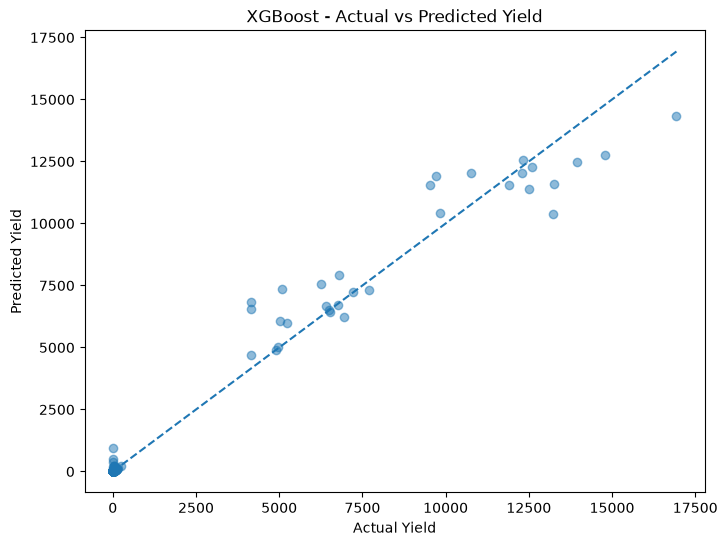

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    xgb_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    xgb_predictions.min()
)

max_value = max(
    y_test.max(),
    xgb_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost - Actual vs Predicted Yield")

plt.show()

In [23]:
xgb_residuals = y_test - xgb_predictions

print("========== RESIDUAL STATISTICS ==========")

print(
    pd.Series(xgb_residuals).describe()
)

========== RESIDUAL STATISTICS ==========
count    3938.000000
mean       -2.100685
std       125.381991
min     -2675.092594
25%        -0.644796
50%        -0.229615
75%         0.272127
max      2834.587133
Name: Yield, dtype: float64


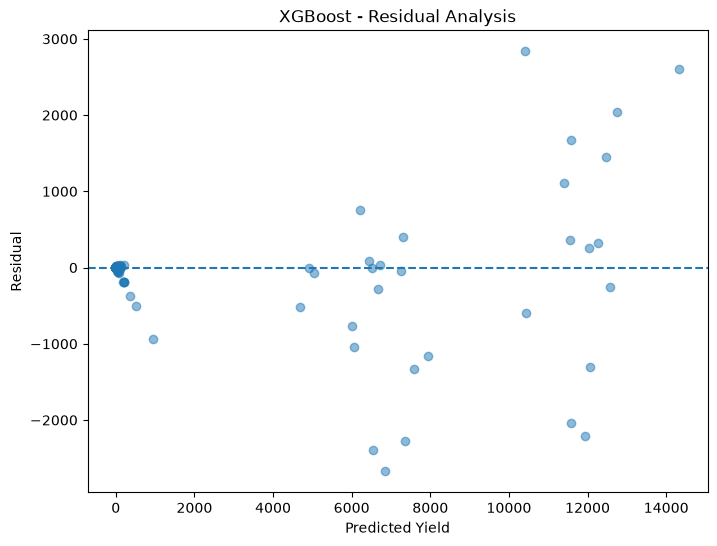

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    xgb_predictions,
    xgb_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("XGBoost - Residual Analysis")

plt.show()

In [25]:
feature_names = preprocessor.get_feature_names_out()

xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("========== TOP 20 FEATURE IMPORTANCES ==========")

xgb_feature_importance.head(20)

========== TOP 20 FEATURE IMPORTANCES ==========


,Feature,Importance
17,cat__Crop_Coconut,0.924307
81,cat__State_Karnataka,0.022979
1,num__Area,0.014665
2,num__Annual_Rainfall,0.013350
94,cat__State_Telangana,0.007317
5,num__Avg_Temperature,0.004790
4,num__Pesticide,0.004066
98,cat__State_West Bengal,0.003309
7,num__Min_Temperature,0.000948
0,num__Crop_Year,0.000876


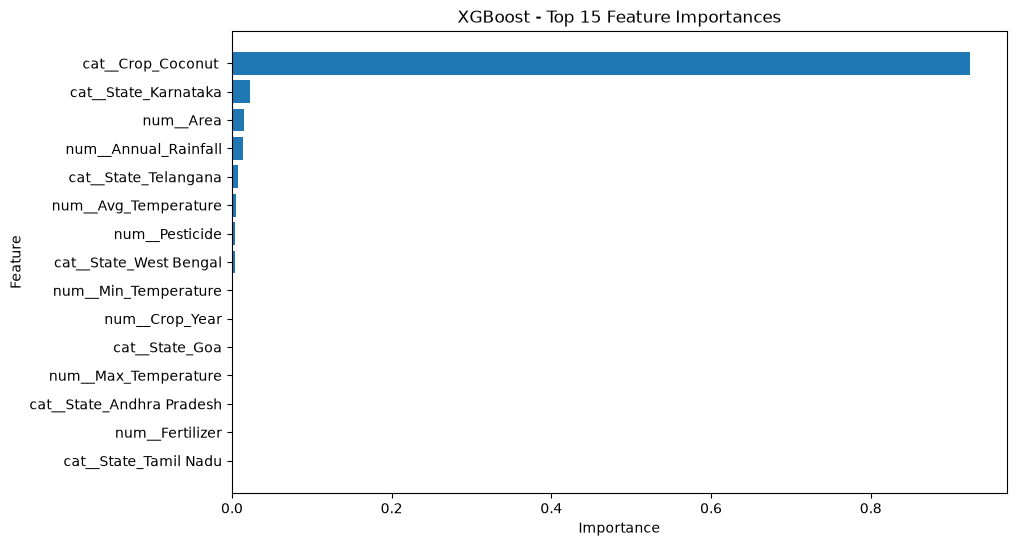

In [26]:
top_features = xgb_feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost - Top 15 Feature Importances")

plt.show()

In [27]:
joblib.dump(
    xgb_model,
    r"C:\Crop Yield Prediction\models\xgboost_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


## XGBoost Model Conclusion

The XGBoost Regressor was successfully trained to predict crop yield using agricultural, environmental, crop, season and state features.

The model was evaluated using MAE, MSE, RMSE and R².

Actual-versus-predicted visualization and residual analysis were performed to examine prediction performance and prediction errors.

Feature importance analysis was also performed to identify important processed features.

The trained XGBoost model and preprocessing pipeline were saved for future use.

The obtained results will be compared with Random Forest and SVR in the model comparison stage.